# 02 — Independence gates and closure scans

Implements gates 1–3 of the pre-registered decision rule (`README.md`) on the
**even-parity half**: factorization-fit goodness of fit per process and total under
the quirk prescriptions; effective-count health; closure R = A/(B·C/D) along
boundary and event-cut scan trajectories with bootstrap covariance; guard-band
variants; the mJJ-sculpting diagnosis; and the non-closure systematic per plane.
Results are written to `gates_even.json` for notebooks 03/04.

In [1]:
import json, os, sys
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep

sys.path.insert(0, os.getcwd())
import abcd_tools as at
import study_setup as ss

hep.style.use("CMS")
plt.rcParams["figure.figsize"] = (9, 7)
# even-parity half of the sample = half the effective luminosity
LUMI_LABEL = r"29.9 fb$^{-1}$ (13 TeV, 2018 sim., even half)"

def cms_label(ax=None):
    hep.cms.label("Work in progress", data=False, rlabel=LUMI_LABEL, ax=ax)

# pre-skim / pre-filter sums of gen weights (see README "Normalization")
SUMW_PRE = {}
SUMW_PRE.update(at.census_sumw_pre(ss.CENSUS_SIGNAL_2MU2E))
SUMW_PRE.update(at.census_sumw_pre(ss.CENSUS_SIGNAL_4MU))
SUMW_PRE.update(at.census_sumw_pre(ss.CENSUS_BKG_UNSKIMMED))
SUMW_PRE.update(ss.SUMW_PRE_OVERRIDES)   # DY rogue-file repair (see study_setup)

# normalization tripwire: a factor outside [1e-5, 1] means a broken denominator
for _s in ss.ANALYSIS_BACKGROUNDS:
    _f = ss.fetch(_s)["metadata"]["scaled_sum_weights"] / SUMW_PRE[_s] / ss.FW.get(_s, 1.0)
    assert 1e-5 < _f <= 1.0, f"normalization factor out of range for {_s}: {_f:.3g}"
SUMW_PRE.update(ss.SUMW_PRE_OVERRIDES)   # DY rogue-file repair (see study_setup)

# normalization tripwire: a factor outside [1e-5, 1] means a broken denominator
for _s in ss.ANALYSIS_BACKGROUNDS:
    _f = ss.fetch(_s)["metadata"]["scaled_sum_weights"] / SUMW_PRE[_s] / ss.FW.get(_s, 1.0)
    assert 1e-5 < _f <= 1.0, f"normalization factor out of range for {_s}: {_f:.3g}"

# Background sums built ONE SAMPLE AT A TIME (holding all 44 samples in memory OOMs
# the interactive node); signals are loaded lazily where needed, one at a time.
# TTJets kept at the campaign 471.7 pb; the NNLO alternative is an explicit rescale.
total_bkg, by_process = ss.accumulate_normalized(list(ss.ANALYSIS_BACKGROUNDS), SUMW_PRE)
def load_sig(s):
    return ss.load_normalized(s, SUMW_PRE)[0]
print(f"accumulated {len(ss.BACKGROUNDS)} backgrounds; scan hists: {len(total_bkg)}")

accumulated 18 backgrounds; scan hists: 8


## Gate 1 — factorization fits

Fit μᵢⱼ = aᵢ·bⱼ on an adaptively rebinned grid (n_eff ≥ 10 per super-bin) for each
plane × process × quirk prescription. How to read it: p > 0.05 everywhere = the
background factorizes = ABCD's core assumption holds; p ≈ 1.0 rows are treated as
variance over-inflation, not passes.

In [2]:
# The tight-WP planes are too sparse for per-process fits (single huge-weight
# events dominate); the meaningful factorization statement is at PRESEL level (no
# dphi/mjj/displacement cuts), where every process has statistics. This amends the
# pre-registered gate-1 wording (tight-WP evaluation is not possible) -- recorded
# openly here and in notebook 04.
def presel_arrays(hists, ch, pname, presc="i"):
    spec = ss.PLANES[ch][pname]
    h = at.get_channel(hists[spec["hist"]], ss.CHANNELS[ch])
    sel = {ax: "sum" for ax in spec["cuts"]}
    sel["parity"] = ("bin", 0)
    vals, var, xe, ye = at.project_plane(h, spec["x"], spec["y"], sel)
    if presc == "ii":
        if "iso" in spec["x"] and xe[0] < 0: vals, var, xe = vals[1:], var[1:], xe[1:]
        if "iso" in spec["y"] and ye[0] < 0: vals, var, ye = vals[:, 1:], var[:, 1:], ye[1:]
    return vals, var, xe, ye

gate1 = {}
for ch in ss.PLANES:
    for pname in ss.PLANES[ch]:
        for presc in ["i", "ii"]:
            key = f"{ch}/{pname}/{presc}"
            ps = {}
            for p in ss.PROCESSES + ["total"]:
                hset = total_bkg if p == "total" else by_process[p]
                vals, var, xe, ye = presel_arrays(hset, ch, pname, presc)
                fit = at.factorization_fit(vals, var) if vals.sum() > 0 else {"pvalue": np.nan}
                ps[p] = fit["pvalue"]
                if p == "total" and np.isfinite(fit.get("pvalue", np.nan)):
                    ps["_chi2ndf"] = f"{fit['chi2']:.1f}/{fit['ndf']}"
            gate1[key] = ps
            line = " ".join(f"{p}:{v:7.3f}" for p, v in ps.items() if not str(p).startswith("_"))
            print(f"{key:34s} {line}  [total chi2/ndf {ps.get('_chi2ndf', '-')}]")

2mu2e/P1_iso_iso/i                 QCD:  0.199 DY:    nan TTJets:  0.744 Diboson:    nan total:  0.029  [total chi2/ndf 10.8/4]


2mu2e/P1_iso_iso/ii                QCD:  0.199 DY:    nan TTJets:  0.924 Diboson:    nan total:  0.477  [total chi2/ndf 1.5/2]


2mu2e/P2_muiso_dphi/i              QCD:  0.371 DY:    nan TTJets:  0.461 Diboson:    nan total:  0.011  [total chi2/ndf 13.0/4]


2mu2e/P2_muiso_dphi/ii             QCD:  0.374 DY:    nan TTJets:  0.910 Diboson:    nan total:  0.011  [total chi2/ndf 13.1/4]


2mu2e/P3_egmiso_dphi/i             QCD:  0.144 DY:    nan TTJets:  0.062 Diboson:    nan total:  0.218  [total chi2/ndf 1.5/1]


...

4mu/Q2_iso0_dphi/ii                QCD:  0.071 DY:    nan TTJets:  0.036 Diboson:    nan total:  0.376  [total chi2/ndf 0.8/1]


4mu/Q3_iso0_pix0/i                 QCD:  0.037 DY:    nan TTJets:    nan Diboson:    nan total:  0.651  [total chi2/ndf 0.2/1]


4mu/Q3_iso0_pix0/ii                QCD:  0.141 DY:    nan TTJets:    nan Diboson:    nan total:  0.119  [total chi2/ndf 2.4/1]
4mu/Q4_pix_pix/i                   QCD:  0.000 DY:    nan TTJets:    nan Diboson:    nan total:  0.000  [total chi2/ndf 29.6/1]
4mu/Q4_pix_pix/ii                  QCD:  0.000 DY:    nan TTJets:    nan Diboson:    nan total:  0.000  [total chi2/ndf 29.6/1]


4mu/Q5_dphi_mjj/i                  QCD:  0.065 DY:    nan TTJets:    nan Diboson:    nan total:  0.000  [total chi2/ndf 106.1/4]


4mu/Q5_dphi_mjj/ii                 QCD:  0.065 DY:    nan TTJets:    nan Diboson:    nan total:  0.000  [total chi2/ndf 106.1/4]


## Gate 2 — statistical health at the working point

n_eff = (Σw)²/Σw² in each region at the SR working point. Regions with n_eff < 10
make the B·C/D error propagation anticonservative (demonstrated in
`test_abcd_tools.py`) — they fail the gate.

In [3]:
gate2 = {}
for ch in ss.PLANES:
    for pname, spec in ss.PLANES[ch].items():
        vals, var, xe, ye = ss.plane_arrays(total_bkg, ch, pname, parity=0)
        reg = at.region_sums(vals, var, xe, ye, spec["xspec"], spec["yspec"])
        ne = {k: at.n_eff(*reg[k]) for k in "ABCD"}
        r, vr = at.closure_ratio(reg)
        gate2[f"{ch}/{pname}"] = {"n_eff": ne, "R": r, "R_err": np.sqrt(vr) if vr > 0 else np.nan,
                                  "yields": {k: reg[k][0] for k in "ABCD"}}
        flag = "" if min(ne.values()) >= 10 else "  <-- FAILS gate 2"
        print(f"{ch}/{pname:18s} A={reg['A'][0]:9.3g} R={r:6.3f}+-{np.sqrt(max(vr,0)):5.3f} "
              f"min_neff={min(ne.values()):7.1f}{flag}")

2mu2e/P1_iso_iso         A=     34.2 R=24.782+-37.091 min_neff=    1.1  <-- FAILS gate 2
2mu2e/P2_muiso_dphi      A=     34.2 R= 1.063+-1.441 min_neff=    1.1  <-- FAILS gate 2


2mu2e/P3_egmiso_dphi     A=     34.2 R= 4.290+-6.951 min_neff=    1.1  <-- FAILS gate 2
2mu2e/P4_muiso_mjj       A=     34.2 R=255.524+-415.887 min_neff=    1.0  <-- FAILS gate 2


2mu2e/P5_muiso_mupix     A=     34.2 R= 3.463+-3.968 min_neff=    1.1  <-- FAILS gate 2
2mu2e/P6_mupix_dphi      A=     34.2 R= 1.034+-1.630 min_neff=    1.1  <-- FAILS gate 2
2mu2e/P7_egmlost_dphi    A=     34.2 R= 5.507+-9.343 min_neff=    1.0  <-- FAILS gate 2


2mu2e/P8_dphi_mjj        A=     34.2 R=11.491+-21.063 min_neff=    1.0  <-- FAILS gate 2


4mu/Q1_iso_iso         A=  0.00263 R= 0.060+-0.097 min_neff=    1.0  <-- FAILS gate 2


4mu/Q2_iso0_dphi       A=  0.00263 R=   nan+-  nan min_neff=    0.0  <-- FAILS gate 2
4mu/Q3_iso0_pix0       A=  0.00263 R= 0.047+-0.085 min_neff=    1.0  <-- FAILS gate 2
4mu/Q4_pix_pix         A=  0.00263 R= 0.475+-0.803 min_neff=    1.0  <-- FAILS gate 2


4mu/Q5_dphi_mjj        A=  0.00263 R=   nan+-  nan min_neff=    0.0  <-- FAILS gate 2


## Gate 3 — closure trends (loose → tight)

Boundary scans (R vs the two plane cuts) and event-cut scans (R vs the |Δφ| and mJJ
thresholds), with scan-point covariance from the per-bin bootstrap. The systematic is
the fitted trend extrapolated to the SR point ⊕ fit error, restricted to points with
n_eff(B, C, D) > 10. How to read the maps: color = R; hatched/blank = statistically
unhealthy; a flat map near 1 is what a good plane looks like.

In [4]:
def boundary_scan(hists, ch, pname, xcuts, ycuts):
    spec = ss.PLANES[ch][pname]
    vals, var, xe, ye = ss.plane_arrays(hists, ch, pname, parity=0)
    R = np.full((len(xcuts), len(ycuts)), np.nan)
    ok = np.zeros_like(R, bool)
    for i, xc in enumerate(xcuts):
        for j, yc in enumerate(ycuts):
            reg = at.region_sums(vals, var, xe, ye, (spec["xspec"][0], xc), (spec["yspec"][0], yc))
            r, vr = at.closure_ratio(reg)
            R[i, j] = r
            ok[i, j] = min(at.n_eff(*reg[k]) for k in "ABCD") >= 10
    return R, ok

# incumbent planes: iso boundary grids on the 0.025 lattice
iso_cuts = [round(0.025 * k, 3) for k in range(2, 21)]
for ch, pname in [("2mu2e", "P1_iso_iso"), ("4mu", "Q1_iso_iso")]:
    R, ok = boundary_scan(total_bkg, ch, pname, iso_cuts, iso_cuts)
    if not ok.any():
        print(f"{ch}/{pname}: every boundary-scan point has min n_eff < 10 - map not shown")
        continue
    fig, ax = plt.subplots()
    m = ax.pcolormesh(iso_cuts, iso_cuts, np.where(ok, R, np.nan).T, vmin=0.5, vmax=1.5, cmap="RdBu_r")
    fig.colorbar(m, ax=ax, label="R = A / (BC/D)")
    spec = ss.PLANES[ch][pname]
    ax.axvline(spec["xspec"][1], color="k", ls="--"); ax.axhline(spec["yspec"][1], color="k", ls="--")
    ax.set_xlabel(f"{spec['x']} boundary"); ax.set_ylabel(f"{spec['y']} boundary")
    ax.legend(title=f"{ch} {pname} closure map", loc="upper right", framealpha=0.85)
    cms_label(ax); plt.show()

2mu2e/P1_iso_iso: every boundary-scan point has min n_eff < 10 - map not shown


4mu/Q1_iso_iso: every boundary-scan point has min n_eff < 10 - map not shown


2mu2e/P1_iso_iso/i: anchor [presel t=1.0] R = 0.621 +- 0.244 pass=True (3/12 healthy)


2mu2e/P1_iso_iso/iii: anchor [presel t=1.0] R = 0.603 +- 0.240 pass=True (3/12 healthy)


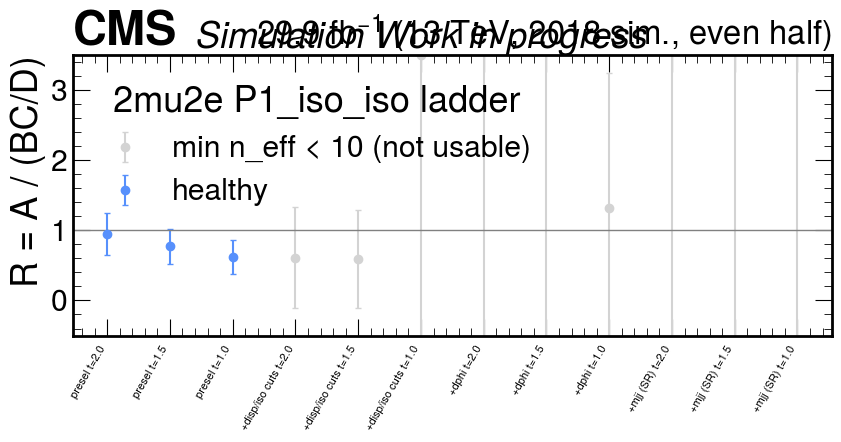

2mu2e/P2_muiso_dphi/i: anchor [presel t=1.0] R = 1.876 +- 0.684 pass=True (2/9 healthy)


2mu2e/P2_muiso_dphi/iii: anchor [presel t=1.0] R = 1.869 +- 0.683 pass=True (2/9 healthy)


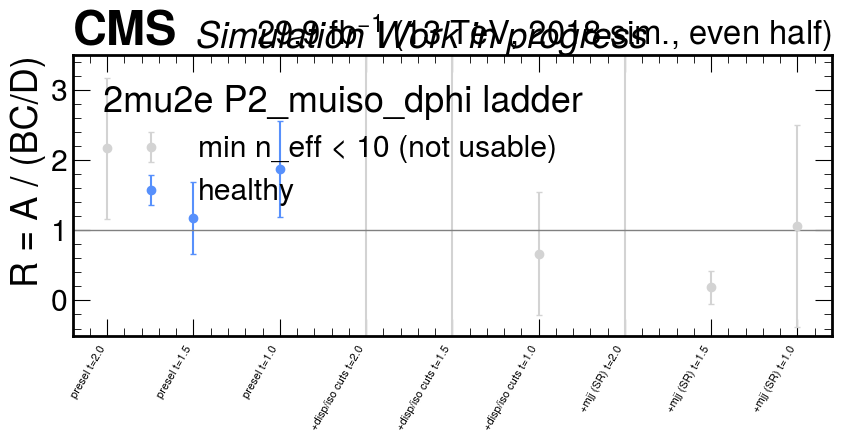

2mu2e/P3_egmiso_dphi/i: NO healthy ladder points


2mu2e/P3_egmiso_dphi/iii: NO healthy ladder points


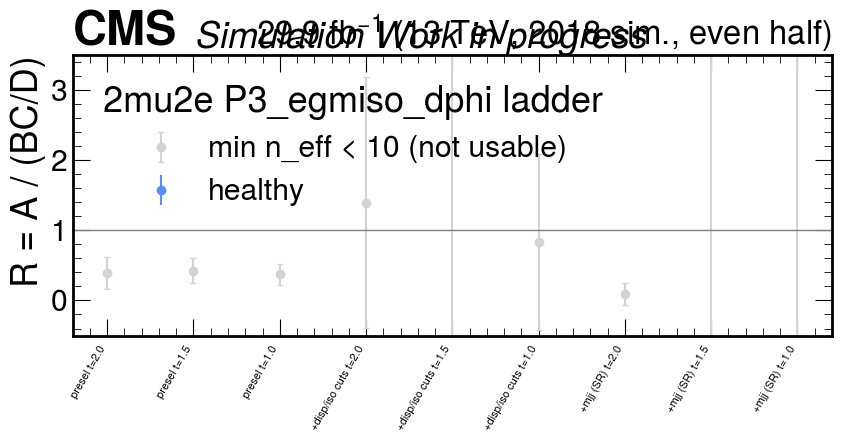

2mu2e/P4_muiso_mjj/i: anchor [presel t=2.0] R = 0.772 +- 0.257 pass=True (1/9 healthy)


2mu2e/P4_muiso_mjj/iii: anchor [presel t=2.0] R = 0.770 +- 0.257 pass=True (1/9 healthy)


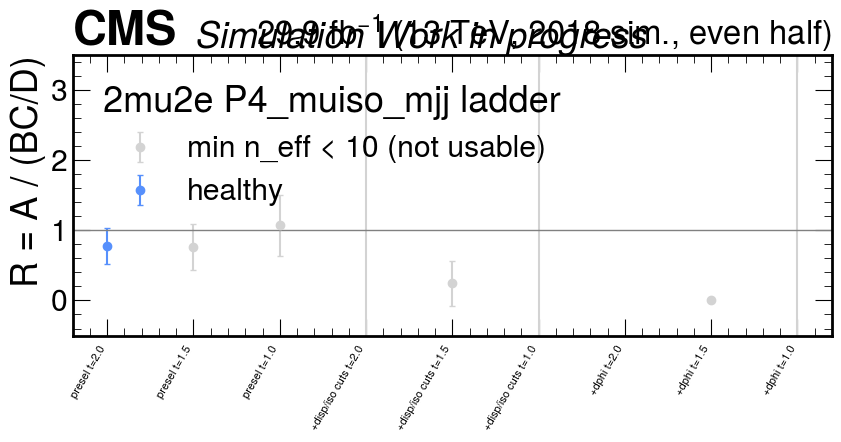

2mu2e/P8_dphi_mjj/i: anchor [presel t=1.0] R = 2.954 +- 0.894 pass=False (2/6 healthy)


2mu2e/P8_dphi_mjj/iii: anchor [presel t=1.0] R = 2.954 +- 0.894 pass=False (2/6 healthy)


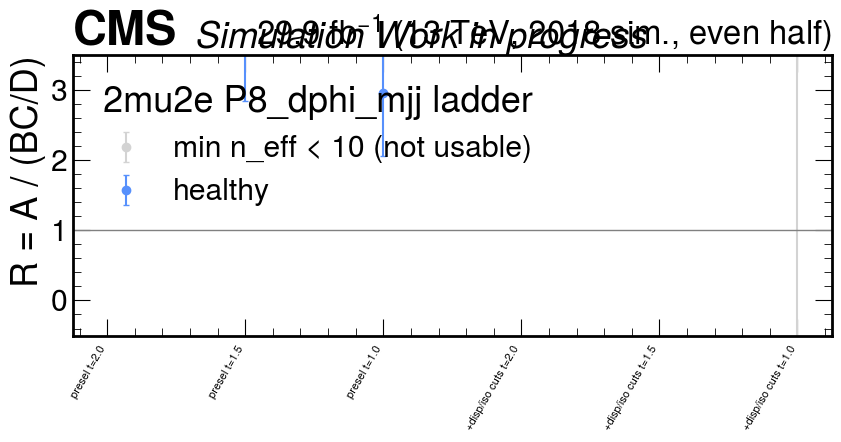

4mu/Q1_iso_iso/i: NO healthy ladder points


4mu/Q1_iso_iso/iii: NO healthy ladder points


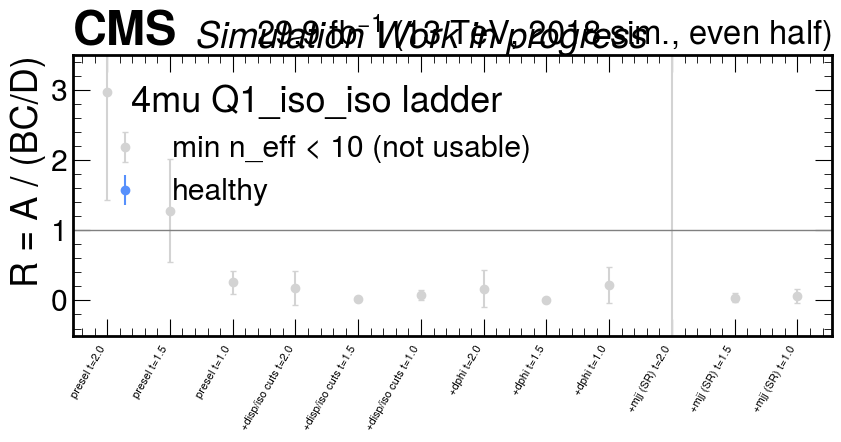

4mu/Q2_iso0_dphi/i: NO healthy ladder points


4mu/Q2_iso0_dphi/iii: anchor [presel t=1.5] R = 0.652 +- 0.304 pass=True (1/9 healthy)


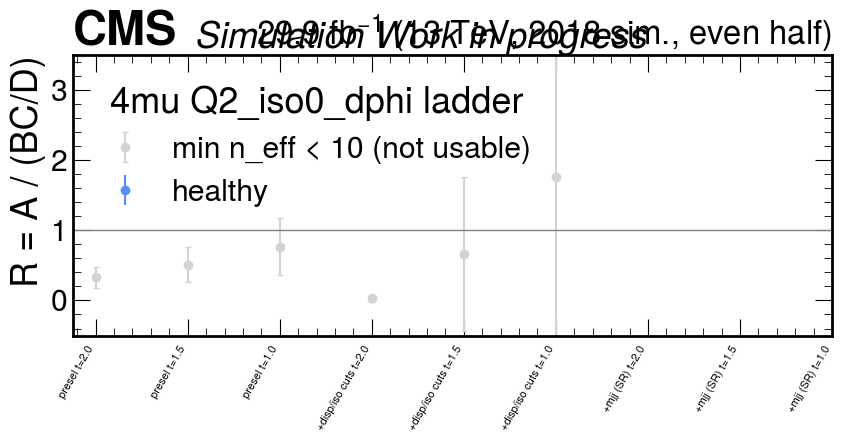

4mu/Q5_dphi_mjj/i: anchor [presel t=1.0] R = 2.429 +- 0.886 pass=True (2/6 healthy)


4mu/Q5_dphi_mjj/iii: anchor [presel t=1.0] R = 2.429 +- 0.886 pass=True (2/6 healthy)


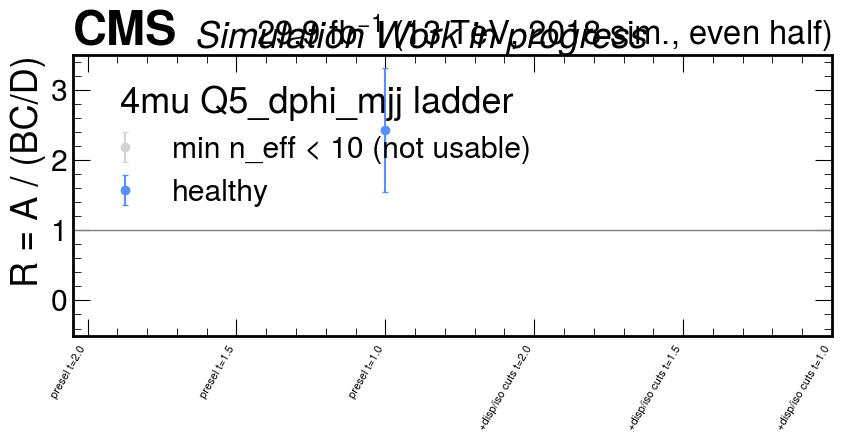

In [5]:
# THE LOOSE->TIGHT LADDER: closure R along a staged tightening that relaxes BOTH
# the event cuts and the plane boundaries (loosest first): presel -> +displacement ->
# +dphi -> +mjj (axes that are the plane axes stay axes), each at boundary scales
# t = 2.0, 1.5, 1.0. Gate 3 anchors at the TIGHTEST stage with min n_eff > 10:
# R there must be consistent with 1 within max(2 sigma, 0.25); the systematic carried
# to the sensitivity notebook is |R - 1| (+) err at that anchor. No extrapolation --
# the unmeasurable tighter stages inherit the anchor systematic (stated openly).
def snap(edges, v):
    e = np.asarray(edges)
    return float(e[int(np.argmin(np.abs(e - v)))])

def staged_points(ch, pname, presc):
    spec = ss.PLANES[ch][pname]
    cuts = spec["cuts"]
    disp = {k: v for k, v in cuts.items() if "disp" in k or "pix" in k or "lost" in k or "iso3" in k or k in ("muiso", "egmiso", "muiso0", "muiso1")}
    stages = [("presel", {})]
    stages.append(("+disp/iso cuts", dict(disp)))
    if "dphi" in cuts:
        d2 = dict(disp); d2["dphi"] = cuts["dphi"]; stages.append(("+dphi", d2))
    if "mjj" in cuts:
        d3 = dict(stages[-1][1]); d3["mjj"] = cuts["mjj"]; stages.append(("+mjj (SR)", d3))
    pts = []
    for si, (slabel, scuts) in enumerate(stages):
        vals, var, xe, ye = ss.plane_arrays(total_bkg, ch, pname, parity=0,
                                            cuts_override=scuts)
        xlo = 0.0 if (presc == "iii" and "iso" in spec["x"] and xe[0] < 0) else None
        ylo = 0.0 if (presc == "iii" and "iso" in spec["y"] and ye[0] < 0) else None
        for t in (2.0, 1.5, 1.0):
            xc = snap(xe[1:-1], spec["xspec"][1] * (t if spec["xspec"][0] == "lt" else 1 / t))
            yc = snap(ye[1:-1], spec["yspec"][1] * (t if spec["yspec"][0] == "lt" else 1 / t))
            kw = dict(xspec=(spec["xspec"][0], xc), yspec=(spec["yspec"][0], yc),
                      xlo=xlo, ylo=ylo)
            reg = at.region_sums(vals, var, xe, ye, **kw)
            ne = min(at.n_eff(*reg[k]) for k in "ABCD")
            r, vr = at.closure_ratio(reg)
            pts.append(dict(stage=si, label=f"{slabel} t={t}", R=r,
                            err=np.sqrt(max(vr, 0)), neff=ne))
    return pts

gate3 = {}
for ch in ss.PLANES:
    for pname in ss.PLANES[ch]:
        if pname in ss.SCREENED_ONLY[ch]:
            continue
        for presc in ["i", "iii"]:
            pts = staged_points(ch, pname, presc)
            healthy = [p for p in pts if p["neff"] >= 10 and np.isfinite(p["R"]) and p["err"] > 0]
            res = {"n_healthy": len(healthy), "ladder": [
                {k: p[k] for k in ("label", "R", "err", "neff")} for p in pts]}
            if healthy:
                anchor = healthy[-1]   # tightest measurable point (ladder is ordered)
                res["anchor_label"] = anchor["label"]
                res["anchor_R"] = anchor["R"]
                res["anchor_err"] = anchor["err"]
                res["anchor_pass"] = bool(abs(anchor["R"] - 1) <= max(2 * anchor["err"], 0.25))
                res["syst"] = abs(anchor["R"] - 1) + anchor["err"]
            gate3[f"{ch}/{pname}/{presc}"] = res
            if healthy:
                print(f"{ch}/{pname}/{presc}: anchor [{res['anchor_label']}] "
                      f"R = {res['anchor_R']:.3f} +- {res['anchor_err']:.3f} "
                      f"pass={res['anchor_pass']} ({len(healthy)}/{len(pts)} healthy)")
            else:
                print(f"{ch}/{pname}/{presc}: NO healthy ladder points")
        # one ladder figure per plane (prescription i)
        pts = staged_points(ch, pname, "i")
        fig, ax = plt.subplots(figsize=(9, 5))
        xs = np.arange(len(pts))
        ok = np.array([p["neff"] >= 10 for p in pts])
        Rs = np.array([p["R"] for p in pts]); errs = np.array([p["err"] for p in pts])
        ax.errorbar(xs[~ok], Rs[~ok], errs[~ok], marker="o", ls="", color="lightgray",
                    capsize=2, label="min n_eff < 10 (not usable)")
        ax.errorbar(xs[ok], Rs[ok], errs[ok], marker="o", ls="", color="C0",
                    capsize=2, label="healthy")
        ax.axhline(1, color="gray", lw=1)
        ax.set_xticks(xs, [p["label"] for p in pts], rotation=60, ha="right", fontsize=8)
        ax.set_ylabel("R = A / (BC/D)"); ax.set_ylim(-0.5, 3.5)
        ax.legend(title=f"{ch} {pname} ladder", loc="upper left", framealpha=0.85)
        cms_label(ax)
        plt.tight_layout(); plt.show()

## How much of the signal region is the isolation quirk?

Share of the A-region background sitting in a sentinel (failed-jet-match) bin, vs the
signal cost of excluding those events. A large share means prescription (i) leaves the
SR dominated by events no sideband constrains — and excluding them (equivalently:
requiring the leading LJs to have a matched AK4 jet) is a genuine selection
improvement, not a binning trick.

In [6]:
for ch, pname, sigs in [("2mu2e", "P1_iso_iso", ss.SIGNALS_2MU2E), ("4mu", "Q1_iso_iso", ss.SIGNALS_4MU)]:
    spec = ss.PLANES[ch][pname]
    vals, var, xe, ye = ss.plane_arrays(total_bkg, ch, pname, parity=0)
    nom = at.region_sums(vals, var, xe, ye, spec["xspec"], spec["yspec"])
    exc = at.region_sums(vals, var, xe, ye, spec["xspec"], spec["yspec"], xlo=0.0, ylo=0.0)
    share = 1 - exc["A"][0] / nom["A"][0] if nom["A"][0] > 0 else float("nan")
    print(f"{ch}/{pname}: bkg A nominal {nom['A'][0]:.4g} -> sentinel-excluded {exc['A'][0]:.4g} "
          f"(sentinel share {share:.1%})")
    for sname in sigs:
        sh = load_sig(sname)
        sv, sw, sxe, sye = ss.plane_arrays(sh, ch, pname, parity=0)
        snom = at.region_sums(sv, sw, sxe, sye, spec["xspec"], spec["yspec"])
        sexc = at.region_sums(sv, sw, sxe, sye, spec["xspec"], spec["yspec"], xlo=0.0, ylo=0.0)
        if snom["A"][0] > 0:
            print(f"   signal cost {sname}: {1 - sexc['A'][0] / snom['A'][0]:.1%}")

2mu2e/P1_iso_iso: bkg A nominal 34.21 -> sentinel-excluded 1.528 (sentinel share 95.5%)


   signal cost 2Mu2E_100GeV_1p2GeV_9p6mm: 32.1%


   signal cost 2Mu2E_100GeV_1p2GeV_96p0mm: 20.0%


   signal cost 2Mu2E_500GeV_1p2GeV_0p019mm: 0.0%


   signal cost 2Mu2E_500GeV_1p2GeV_1p9mm: 4.0%


...

   signal cost 4Mu_1000GeV_1p2GeV_9p6mm: 26.3%


   signal cost 4Mu_500GeV_0p25GeV_0p4mm: 9.0%


   signal cost 4Mu_500GeV_0p25GeV_4p0mm: 34.0%


   signal cost 4Mu_500GeV_5p0GeV_8p0mm: 8.7%


   signal cost 4Mu_500GeV_5p0GeV_80p0mm: 46.2%


## Guard bands and quirk prescriptions

The same closure evaluated with 1–2 guard bins around each boundary (the user's
"gaps" idea) and under prescriptions (i)/(ii)/(iii). A verdict that flips under these
variations is not robust.

In [7]:
for ch, pname in [("2mu2e", "P1_iso_iso"), ("4mu", "Q1_iso_iso")]:
    spec = ss.PLANES[ch][pname]
    vals, var, xe, ye = ss.plane_arrays(total_bkg, ch, pname, parity=0)
    print(f"--- {ch}/{pname}")
    for label, kw in [("nominal (i)", {}),
                      ("guard 1 bin", dict(xguard=1, yguard=1)),
                      ("guard 2 bins", dict(xguard=2, yguard=2)),
                      ("sentinel excluded (iii)", dict(xlo=0.0, ylo=0.0))]:
        reg = at.region_sums(vals, var, xe, ye, spec["xspec"], spec["yspec"], **kw)
        r, vr = at.closure_ratio(reg)
        print(f"  {label:24s} R = {r:6.3f} +- {np.sqrt(max(vr,0)):5.3f}  A = {reg['A'][0]:9.4g}")

--- 2mu2e/P1_iso_iso
  nominal (i)              R = 24.782 +- 37.091  A =     34.21
  guard 1 bin              R = 275.644 +- 385.153  A =      34.2
  guard 2 bins             R = 13.672 +- 16.902  A =     1.486
  sentinel excluded (iii)  R =  1.107 +- 1.445  A =     1.528


--- 4mu/Q1_iso_iso
  nominal (i)              R =  0.060 +- 0.097  A =  0.002632
  guard 1 bin              R =  0.060 +- 0.097  A =  0.002632
  guard 2 bins             R =  0.060 +- 0.097  A =  0.002632
  sentinel excluded (iii)  R =    nan +-   nan  A =         0


## mJJ sculpting diagnosis + κ + round-2 validation region

Closure and factorization split by mJJ region, per process — the head-on version of
the sculpting question. The low-mJJ region is the designated round-2 (data) validation
region if it stays signal-depleted (checked in 03).

In [8]:
for ch, pname in [("2mu2e", "P1_iso_iso"), ("4mu", "Q1_iso_iso")]:
    spec = ss.PLANES[ch][pname]
    h = at.get_channel(total_bkg[spec["hist"]], ss.CHANNELS[ch])
    print(f"--- {ch}/{pname}")
    for lab, mjjsel in [("mJJ >= 150 (SR)", ("ge", 150.0)), ("mJJ < 150 (VR)", ("window", 0.0, 150.0))]:
        sel = dict(spec["cuts"]); sel["mjj"] = mjjsel; sel["parity"] = ("bin", 0)
        vals, var, xe, ye = at.project_plane(h, spec["x"], spec["y"], sel)
        reg = at.region_sums(vals, var, xe, ye, spec["xspec"], spec["yspec"])
        r, vr = at.closure_ratio(reg)
        ne = min(at.n_eff(*reg[k]) for k in "ABCD")
        corr = at.weighted_correlation(vals, xe, ye)
        print(f"  {lab:18s} R = {r:6.3f}+-{np.sqrt(max(vr,0)):5.3f}  min_neff = {ne:6.1f}  r_w = {corr:6.3f}")

--- 2mu2e/P1_iso_iso


  mJJ >= 150 (SR)    R = 24.782+-37.091  min_neff =    1.1  r_w =  0.032


  mJJ < 150 (VR)     R =  0.013+-0.022  min_neff =    1.0  r_w =  0.320
--- 4mu/Q1_iso_iso


  mJJ >= 150 (SR)    R =  0.060+-0.097  min_neff =    1.0  r_w =  0.132


  mJJ < 150 (VR)     R =    nan+-  nan  min_neff =    0.0  r_w = -0.077


## Derived and discrete planes (phase-space expansion)

Planes built offline from the same histograms: the count of tight-isolation LJs
(N_tight ∈ {0,1,2} — the classic tight-object contingency), the count of
jet-matched LJs (turning the isolation quirk into an axis that CONSTRAINS the
no-jet population), and the egm-LJ composition (photon-only vs electron-containing).
Categorical boundaries cannot be scanned, so their loose→tight validation comes
entirely from the event-cut stages of the ladder.

In [9]:
STAGE_MENU = {
    "D1_ntight_dphi":  [("presel", {}), ("+disp", {"mudisp": ("lt", 2.5), "egmdisp": ("ge", 0.5)}),
                        ("+mjj100", {"mudisp": ("lt", 2.5), "egmdisp": ("ge", 0.5), "mjj": ("ge", 100.0)}),
                        ("+mjj150 (SR)", {"mudisp": ("lt", 2.5), "egmdisp": ("ge", 0.5), "mjj": ("ge", 150.0)})],
    "D2_ntight_mjj":   [("presel", {}), ("+disp", {"mudisp": ("lt", 2.5), "egmdisp": ("ge", 0.5)}),
                        ("+dphi (SR)", {"mudisp": ("lt", 2.5), "egmdisp": ("ge", 0.5), "dphi": ("ge", 2.0)})],
    "D3_jetmatch_dphi": [("presel", {}), ("+disp", {"mudisp": ("lt", 2.5), "egmdisp": ("ge", 0.5)}),
                         ("+mjj150 (SR)", {"mudisp": ("lt", 2.5), "egmdisp": ("ge", 0.5), "mjj": ("ge", 150.0)})],
    "D4_photononly_dphi": [("presel", {"egmiso": ("window", 0.0, 0.10), "muiso3": ("lt", 0.25)}),
                           ("+disp", {"egmiso": ("window", 0.0, 0.10), "muiso3": ("lt", 0.25), "mudisp2": ("lt", 2.5)}),
                           ("+mjj150 (SR)", {"egmiso": ("window", 0.0, 0.10), "muiso3": ("lt", 0.25), "mudisp2": ("lt", 2.5), "mjj": ("ge", 150.0)})],
    "D5_ntight_dphi":  [("presel", {}), ("+disp", {"mudisp0": ("lt", 2.5), "mudisp1": ("lt", 2.5)}),
                        ("+mjj150 (SR)", {"mudisp0": ("lt", 2.5), "mudisp1": ("lt", 2.5), "mjj": ("ge", 150.0)})],
}
for ch in ss.DERIVED_PLANES:
    for dname, spec in ss.DERIVED_PLANES[ch].items():
        v, w, xe, ye = ss.derived_plane_arrays(total_bkg, ch, spec["kind"], parity=0,
                                               cuts_override={})
        fit = at.factorization_fit(v, w)
        gate1[f"{ch}/{dname}/i"] = {"total": fit["pvalue"]}
        pval = fit["pvalue"]
        print(f"{ch}/{dname}: presel factorization p = {pval:.3f}")
        pts = []
        for slabel, scuts in STAGE_MENU[dname]:
            v, w, xe, ye = ss.derived_plane_arrays(total_bkg, ch, spec["kind"], parity=0,
                                                   cuts_override=scuts)
            reg = at.region_sums(v, w, xe, ye, spec["xspec"], spec["yspec"])
            ne = min(at.n_eff(*reg[k]) for k in "ABCD")
            r, vr = at.closure_ratio(reg)
            pts.append(dict(label=slabel, R=r, err=np.sqrt(max(vr, 0)), neff=ne))
        healthy = [q for q in pts if q["neff"] >= 10 and np.isfinite(q["R"]) and q["err"] > 0]
        res = {"n_healthy": len(healthy),
               "ladder": [{k: q[k] for k in ("label", "R", "err", "neff")} for q in pts]}
        if healthy:
            anc = healthy[-1]
            res.update(anchor_label=anc["label"], anchor_R=anc["R"], anchor_err=anc["err"],
                       anchor_pass=bool(abs(anc["R"] - 1) <= max(2 * anc["err"], 0.25)),
                       syst=abs(anc["R"] - 1) + anc["err"])
        for q in pts:
            flag = "" if q["neff"] >= 10 else "   (unhealthy)"
            print(f"     {q['label']:16s} R = {q['R']:6.3f} +- {q['err']:5.3f}  min_neff = {q['neff']:7.1f}{flag}")
        if healthy:
            print(f"   -> anchor [{res['anchor_label']}] pass={res['anchor_pass']}")
        else:
            print("   -> NO healthy ladder points")
        gate3[f"{ch}/{dname}/i"] = res
        gate3[f"{ch}/{dname}/iii"] = res

2mu2e/D1_ntight_dphi: presel factorization p = 0.695


     presel           R =  0.593 +- 0.341  min_neff =     4.8   (unhealthy)
     +disp            R =  0.170 +- 0.193  min_neff =     1.8   (unhealthy)
     +mjj100          R =  0.024 +- 0.024  min_neff =     2.0   (unhealthy)
     +mjj150 (SR)     R =  0.019 +- 0.020  min_neff =     2.0   (unhealthy)
   -> NO healthy ladder points
2mu2e/D2_ntight_mjj: presel factorization p = 0.548


     presel           R =  2.488 +- 1.346  min_neff =     6.1   (unhealthy)
     +disp            R = 13.569 +- 17.180  min_neff =     1.4   (unhealthy)
     +dphi (SR)       R =  2.544 +- 3.423  min_neff =     1.0   (unhealthy)
   -> NO healthy ladder points
2mu2e/D3_jetmatch_dphi: presel factorization p = nan


     presel           R =  4.344 +- 5.683  min_neff =     1.0   (unhealthy)
     +disp            R =  0.000 +- 0.000  min_neff =     1.0   (unhealthy)
     +mjj150 (SR)     R =  0.000 +- 0.000  min_neff =     1.0   (unhealthy)
   -> NO healthy ladder points
2mu2e/D4_photononly_dphi: presel factorization p = 0.199
     presel           R =  2.748 +- 2.409  min_neff =     1.8   (unhealthy)
     +disp            R = 183.629 +- 289.383  min_neff =     1.1   (unhealthy)
     +mjj150 (SR)     R = 4063.335 +- 6361.734  min_neff =     1.1   (unhealthy)
   -> NO healthy ladder points


4mu/D5_ntight_dphi: presel factorization p = 0.229


     presel           R =  0.035 +- 0.025  min_neff =     3.3   (unhealthy)
     +disp            R =    nan +-   nan  min_neff =     0.0   (unhealthy)
     +mjj150 (SR)     R =    nan +-   nan  min_neff =     0.0   (unhealthy)
   -> NO healthy ladder points


## Extended ABCD: the all-sidebands estimator

The factorization-fit prediction of A (per-object pass rates measured from every
sideband bin simultaneously — the per-LJ fake-factor method). Same independence
assumption as B·C/D, several times the statistical power on toys. Compared against
plain ABCD at preselection. In the extremely sparse tight MC regions the current
implementation is unstable (single large-weight bins dominate the fitted marginals),
so tight-region numbers are deliberately NOT quoted; maturing the estimator there is
a data-round item, where sparsity disappears.

In [10]:
for ch, pname in [("2mu2e", "P1_iso_iso"), ("2mu2e", "P2_muiso_dphi"),
                  ("2mu2e", "P4_muiso_mjj"), ("4mu", "Q2_iso0_dphi")]:
    spec = ss.PLANES[ch][pname]
    for slabel, scuts in [("presel", {})]:
        vals, var, xe, ye = ss.plane_arrays(total_bkg, ch, pname, parity=0,
                                            cuts_override=scuts)
        reg = at.region_sums(vals, var, xe, ye, spec["xspec"], spec["yspec"])
        plain, plain_var = at.abcd_prediction(reg)
        a_obs, a_var, ext, ext_var = at.extended_prediction(
            vals, var, xe, ye, spec["xspec"], spec["yspec"], n_boot=200)
        pe = np.sqrt(max(plain_var, 0)); ee = np.sqrt(max(ext_var, 0))
        note = "   <- ext err smaller" if ee < pe else ""
        print(f"{ch}/{pname} [{slabel}]: A_obs = {a_obs:9.4g}  "
              f"BC/D = {plain:9.4g} +- {pe:.3g}   extended = {ext:9.4g} +- {ee:.3g}{note}")

2mu2e/P1_iso_iso [presel]: A_obs =       845  BC/D =      1362 +- 414   extended =      1454 +- 398   <- ext err smaller


2mu2e/P2_muiso_dphi [presel]: A_obs =      7906  BC/D =      4214 +- 1.14e+03   extended =      4214 +- 1.11e+03   <- ext err smaller


2mu2e/P4_muiso_mjj [presel]: A_obs =      3637  BC/D =      3387 +- 1.18e+03   extended =      3387 +- 1.24e+03


4mu/Q2_iso0_dphi [presel]: A_obs =      1946  BC/D =      2539 +- 1.03e+03   extended =      2631 +- 1.03e+03   <- ext err smaller


## Low-mass / high-mass mJJ regions

Instead of discarding mJJ < 150, gates evaluated separately in low- and high-mass
regions (boundaries at 100 and 150 — both exact bin edges), for planes whose presel
factorization passed. A plane that closes in both regions supports a two-region
search (low-mass SR + high-mass SR).

In [11]:
for ch, pname in [("2mu2e", "P2_muiso_dphi"), ("4mu", "Q2_iso0_dphi")]:
    spec = ss.PLANES[ch][pname]
    print(f"--- {ch}/{pname}")
    for lab, mspec in [("mJJ < 100", ("window", 0.0, 100.0)),
                       ("100 <= mJJ < 150", ("window", 100.0, 150.0)),
                       ("mJJ < 150", ("window", 0.0, 150.0)),
                       ("mJJ >= 150", ("ge", 150.0))]:
        cuts = dict(spec["cuts"]); cuts["mjj"] = mspec
        vals, var, xe, ye = ss.plane_arrays(total_bkg, ch, pname, parity=0, cuts_override=cuts)
        reg = at.region_sums(vals, var, xe, ye, spec["xspec"], spec["yspec"])
        ne = min(at.n_eff(*reg[k]) for k in "ABCD")
        r, vr = at.closure_ratio(reg)
        print(f"  {lab:18s} R = {r:6.3f} +- {np.sqrt(max(vr,0)):5.3f}  min_neff = {ne:6.1f}")

--- 2mu2e/P2_muiso_dphi
  mJJ < 100          R =    nan +-   nan  min_neff =    0.0


  100 <= mJJ < 150   R =  0.589 +- 0.884  min_neff =    1.0
  mJJ < 150          R =  0.065 +- 0.106  min_neff =    1.0


  mJJ >= 150         R =  1.063 +- 1.441  min_neff =    1.1
--- 4mu/Q2_iso0_dphi


  mJJ < 100          R =    nan +-   nan  min_neff =    0.0


  100 <= mJJ < 150   R =    nan +-   nan  min_neff =    0.0


  mJJ < 150          R =  0.134 +- 0.230  min_neff =    1.0


  mJJ >= 150         R =    nan +-   nan  min_neff =    0.0


In [12]:
# persist gate results for notebooks 03/04
out = {"gate1": gate1, "gate2": {k: {"n_eff": v["n_eff"], "R": v["R"], "R_err": v["R_err"],
                                     "yields": v["yields"]} for k, v in gate2.items()},
       "gate3": gate3}
json.dump(out, open(os.path.join(ss.WORKDIR, "gates_even.json"), "w"), indent=1, default=float)
print("wrote gates_even.json")

wrote gates_even.json
